# Ejercicio 2
### UDLA
#### Decisiones y Simulacion
#### Fecha emisión: 2026-09-22
#### Fecha entrega: 2026-09-29

> **Nota:** por instrucción del estudiante, este notebook **no incluye la parte del video**. Se entrega en su lugar el desarrollo **paso a paso**, con celdas de texto que explican cada decisión y celdas de código comentadas. El estilo de código sigue el mismo usado en las dos clases de referencia entregadas: `Clase1.ipynb` y `Semana_7_260915_Estudiantes_UDLA_DyS1.ipynb` (creación de DataFrame, `read_csv`/`read_excel`, `describe`, `value_counts`, `sort_values`, `loc`/`iloc`, `isna`/`fillna`, operador lambda con `.apply()`, `groupby`, `merge` y gráficos con `matplotlib`).
>
> **Sobre los datos:** este notebook usa el archivo real `data/Dataset_S7.xlsx` entregado por el profesor (360 filas, 17 columnas: `ID, Nombre, Apellido, Edad, Ciudad, Genero, Ingreso Mensual, Horas Trabajo Semana, Antiguedad Meses, Satisfaccion, Compras Mes, Gasto Mensual, Departamento, Modalidad, Fecha Ingreso, Estado, Evaluacion`).

## 📊 Tabla resumen: qué mide cada pregunta
| # | Pregunta | Métrica comercial | Decisión de negocios |
|---|----------|--------------------|-----------------------|
| 1 | Registros únicos | Volumen de cartera | Dimensionar el mercado interno |
| 2 | Ingreso promedio | Ticket promedio | Benchmark de compensación |
| 3 | Distribución por ciudad | Cobertura geográfica | Expansión territorial |
| 4 | Gasto total | Facturación interna | Presupuesto de compensaciones |
| 5 | Estado | Base activa | Retención de talento |
| 6 | Gasto por depto. | Mix de inversión | Priorizar presupuesto |
| 7 | Ingreso por modalidad | Eficiencia operativa | Política de teletrabajo |
| 8 | Top ciudades por gasto | Segmentos rentables | Foco comercial |
| 9 | Satisfacción vs gasto | ROI de compensación | Ajuste de beneficios |
| 10 | Tendencia anual | Evolución de costos | Proyección financiera |
| 11 | Evaluación por depto. | Performance | Planes de mejora |
| 12 | Segmentación por ingreso | Cliente interno | Segmentación de beneficios |
| 13 | Top deptos. por gasto | Pareto | Priorización 80/20 |
| 14 | Ciudad × Modalidad | Rentabilidad cruzada | Optimización de recursos |
| 15 | Exportación + resumen | Deliverable | Informe a dirección |

## Paso 1 — Importar librerías
Igual que en las clases de referencia, importamos `pandas` para trabajar con DataFrames, `numpy` para operaciones numéricas, y `matplotlib`/`seaborn` para los gráficos que pide el nivel avanzado (P13 y P14).

In [1]:
# CELDA 1: Importar librerías (VS Code o en Google Colaboratory)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Paso 2 — Leer el archivo Excel
Usamos `pd.read_excel` (misma lógica que `pd.read_csv` en las clases de referencia): definimos la ruta (`path`) y cargamos el archivo en un DataFrame `df`.

In [2]:
# CELDA 2: Leer el archivo Excel
path = 'data/Dataset_S7.xlsx'
df = pd.read_excel(path)
df.head()

,ID,Nombre,Apellido,Edad,Ciudad,Genero,Ingreso Mensual,Horas Trabajo Semana,Antiguedad Meses,Satisfaccion,Compras Mes,Gasto Mensual,Departamento,Modalidad,Fecha Ingreso,Estado,Evaluacion
0,1001,Sofía,Pérez,64.0,Santiago,Masculino,895864.0,48,12,6.0,11,265404,Marketing,Remoto,2020-01-01 00:00:00,Activo,1.5
1,1002,Catalina,Contreras,47.0,Concepción,femenino,742231.0,44,49,3.0,0,322523,Finanzas,Remoto,2020-01-04 00:00:00,Activo,3.8
2,1003,Javiera,Díaz,NaN,La Serena,Masculino,1155290.0,20,42,10.0,6,37297,Ventas,Presencial,2020-01-07 00:00:00,Activo,2.8
3,1004,Diego,González,65.0,Santiago,Masculino,614053.0,36,166,5.0,8,529346,Finanzas,Remoto,2020-01-10 00:00:00,Activo,5.9
4,1005,Sofía,Pérez,34.0,Valparaíso,Femenino,1043586.0,36,82,6.0,2,140234,TI,Híbrido,2020-01-13 00:00:00,Activo,1.3


## Paso 3 — Diagnóstico de calidad
Antes de limpiar cualquier dato hay que entender qué tan "sucio" está el dataset. Repetimos las exploraciones vistas en clase (`shape`, `dtypes`, `describe`, `memory_usage().sum()`) y agregamos nulos y duplicados, que son la base para diseñar la limpieza de la CELDA 4.

In [3]:
# CELDA 3: Diagnóstico de calidad
print('=== INFORMACIÓN GENERAL - NUMERO DE COLUMNAS Y FILAS ===')
print(df.shape)

mem_bytes = df.memory_usage().sum()
print(f'Memoria utilizada: {mem_bytes:,} bytes')

print('\n=== TIPOS DE DATOS ===')
print(df.dtypes)

print('\n=== VALORES NULOS POR COLUMNA ===')
print(df.isnull().sum())

print('\n=== DUPLICADOS ===')
print(df.duplicated().sum())

print('\n=== ESTADÍSTICAS NUMÉRICAS ===')
print(df.describe())

=== INFORMACIÓN GENERAL - NUMERO DE COLUMNAS Y FILAS ===
(360, 17)
Memoria utilizada: 49,092 bytes

=== TIPOS DE DATOS ===
ID                        int64
Nombre                      str
Apellido                    str
Edad                    float64
Ciudad                      str
Genero                      str
Ingreso Mensual         float64
Horas Trabajo Semana      int64
Antiguedad Meses          int64
Satisfaccion            float64
Compras Mes               int64
Gasto Mensual             int64
Departamento                str
Modalidad                   str
Fecha Ingreso            object
Estado                      str
Evaluacion              float64
dtype: object

=== VALORES NULOS POR COLUMNA ===
ID                       0
Nombre                   0
Apellido                 0
Edad                    12
Ciudad                   9
Genero                   0
Ingreso Mensual         14
Horas Trabajo Semana     0
Antiguedad Meses         0
Satisfaccion             7
Compras Mes   

**Lo que encontramos en el diagnóstico** (y que la CELDA 4 corrige punto por punto):

- **10 filas duplicadas** (mismo `ID` repetido con todos sus datos idénticos).
- **Nombres de columna** con espacios y mayúsculas (`Ingreso Mensual`, `Fecha Ingreso`, etc.).
- **Texto sucio**: `Genero` trae `'femenino'` en minúscula; `Ciudad` trae `' Valparaíso '` con espacios, `'santiago'`/`'Santiago '` con variaciones de mayúscula/espacio y **`'Santiagoo'`** con una letra de más (typo real); `Departamento` trae `' ventas '` con espacios/minúscula; `Modalidad` trae `'remoto'` en minúscula.
- **`Edad`**: 12 valores nulos y 5 valores imposibles (`-5` y `250`).
- **`Fecha Ingreso`**: 11 valores no interpretables como fecha (`'40/13/2023'`, `'31/02/2022'`, `'99/99/2020'`, `'fecha desconocida'` y celdas vacías).
- **`Ingreso Mensual`**: 14 nulos y 4 outliers extremos en $15.000.000.
- **`Gasto Mensual`**: 3 outliers extremos en $5.000.000.
- **`Satisfaccion`**: 7 nulos.

## Paso 4 — Limpieza adaptada al Dataset_S7
Trabajamos siempre sobre una copia (`df_clean = df.copy()`) y avanzamos **en el mismo orden que trae la plantilla** (los 10 puntos numerados), aplicando exactamente lo detectado en el diagnóstico:

1. **Duplicados**: `drop_duplicates()` elimina las 10 filas repetidas.
2. **Nombres de columnas**: se pasan a minúsculas y sin espacios (`ingreso_mensual`, `fecha_ingreso`, etc.).
3. **Strings**: `str.strip()` + `str.title()` homogeniza espacios y mayúsculas/minúsculas en `genero`, `ciudad`, `departamento`, `modalidad`, `estado`.
4. **Typos**: `'Santiagoo'` → `'Santiago'`. Además, como `str.title()` rompe las siglas (`'RRHH'` → `'Rrhh'`, `'TI'` → `'Ti'`), las restauramos con el mismo diccionario de reemplazo.
5. **Fechas**: `pd.to_datetime(..., errors='coerce')` convierte las 11 fechas inválidas en `NaT` en lugar de romper la ejecución.
6. **Numéricas**: `ingreso_mensual`, `gasto_mensual`, `satisfaccion` y `evaluacion` se fuerzan a numérico con `pd.to_numeric` y sus nulos se completan con la **mediana** de cada columna.
7. **Nulos categóricos**: se rellenan con la moda (valor más frecuente) de cada columna de texto.
8. **Edades inválidas**: nulas, negativas o mayores a 100 se reemplazan por la mediana de las edades válidas, usando un **operador lambda** dentro de `.apply()` (misma técnica que `df_iris['longitud_petalo'].apply(lambda x: -x)` de la clase de referencia).
9. **Outliers extremos**: ingresos > 10.000.000 y gastos > 3.000.000 se reemplazan por la mediana de los valores "normales".
10. **Año/mes de ingreso**: se extraen de `fecha_ingreso` para poder responder P10 (tendencia anual).

In [4]:
# CELDA 4: Limpieza adaptada al Dataset_S7
df_clean = df.copy()

# 1. Eliminar duplicados
df_clean = df_clean.drop_duplicates()

# 2. Normalizar nombres de columnas
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# 3. Limpiar strings (Ciudad, Genero, Departamento, Modalidad, Estado)
columnas_texto = ['genero', 'ciudad', 'departamento', 'modalidad', 'estado']
for col in columnas_texto:
    df_clean[col] = df_clean[col].str.strip().str.title()

# 4. Corregir typos específicos
correcciones = {
    'Santiagoo': 'Santiago',  # typo con letra de más
    'Rrhh': 'RRHH',           # sigla que el str.title() rompe
    'Ti': 'TI',                # sigla que el str.title() rompe
}
for col in ['ciudad', 'departamento']:
    df_clean[col] = df_clean[col].replace(correcciones)

# 5. Convertir fecha_ingreso a datetime (los inválidos serán NaT)
df_clean['fecha_ingreso'] = pd.to_datetime(df_clean['fecha_ingreso'], errors='coerce')

# 6. Convertir columnas numéricas (y completar nulos con la mediana)
columnas_numericas = ['ingreso_mensual', 'gasto_mensual', 'satisfaccion', 'evaluacion']
for col in columnas_numericas:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 7. Rellenar nulos en categóricas
for col in columnas_texto:
    moda = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(moda)

# 8. Corregir edades inválidas (negativas, > 100 o nulas)
edad_valida = df_clean['edad'].between(0, 100)
mediana_edad = df_clean.loc[edad_valida, 'edad'].median()
# Operador lambda: reemplaza por la mediana los valores nulos o fuera de rango
df_clean['edad'] = df_clean['edad'].apply(lambda x: mediana_edad if pd.isna(x) or x < 0 or x > 100 else x)

# 9. Tratar outliers extremos en ingreso_mensual (> 10000000) y gasto_mensual (> 3000000)
# Se consideran > 10.000.000 como valores atípicos probables
mediana_ingreso = df_clean.loc[df_clean['ingreso_mensual'] <= 10_000_000, 'ingreso_mensual'].median()
mediana_gasto = df_clean.loc[df_clean['gasto_mensual'] <= 3_000_000, 'gasto_mensual'].median()
df_clean.loc[df_clean['ingreso_mensual'] > 10_000_000, 'ingreso_mensual'] = mediana_ingreso
df_clean.loc[df_clean['gasto_mensual'] > 3_000_000, 'gasto_mensual'] = mediana_gasto

# 10. Extraer año y mes de ingreso
df_clean['anio_ingreso'] = df_clean['fecha_ingreso'].dt.year
df_clean['mes_ingreso'] = df_clean['fecha_ingreso'].dt.month

# Reporte
print('Dataset limpio:', df_clean.shape)
print('Nulos restantes:', df_clean.isnull().sum().sum())
print('\nNulos por columna:')
print(df_clean.isnull().sum())

Dataset limpio: (350, 19)
Nulos restantes: 30

Nulos por columna:
id                       0
nombre                   0
apellido                 0
edad                     0
ciudad                   0
genero                   0
ingreso_mensual          0
horas_trabajo_semana     0
antiguedad_meses         0
satisfaccion             0
compras_mes              0
gasto_mensual            0
departamento             0
modalidad                0
fecha_ingreso           10
estado                   0
evaluacion               0
anio_ingreso            10
mes_ingreso             10
dtype: int64


**Sobre los nulos restantes:** 10 registros traían una fecha de ingreso no recuperable (texto inválido o celda vacía). Al convertirlas quedan como `NaT`, y por lo tanto `anio_ingreso`/`mes_ingreso` también quedan nulos solo para esas filas puntuales — es correcto no inventar una fecha que no existe. El resto del dataset queda 100% limpio.

**Nota de transparencia:** el diagnóstico también mostró 3 registros con `Satisfaccion = 15`, por encima de la escala habitual 1-10. Como el enunciado no define una escala fija a la cual acotar `Satisfaccion` (a diferencia de `ingreso_mensual`/`gasto_mensual`, donde sí se dan umbrales explícitos), se dejan tal cual están para no inventar una corrección no solicitada; quedan reflejados en el análisis de P9.

## 🟢 Nivel Básico (Preguntas 1–5)

1- P1. ¿Cuántos colaboradores/clientes únicos hay tras eliminar duplicados?
2- P2. ¿Cuál es el ingreso mensual promedio de la empresa?
3- P3. ¿Cómo se distribuye la cartera por ciudad?
4- P4. ¿Cuál es el gasto mensual total del segmento?
5- P5. ¿Cuántos colaboradores están activos vs inactivos vs licencia?

### P1. Registros únicos
Como ya eliminamos duplicados en la CELDA 4, `df_clean` contiene solo registros únicos. Verificamos contando filas y, de forma cruzada, contando valores únicos de `id`.

In [5]:
# P1: Registros únicos tras eliminar duplicados
n_unicos = df_clean['id'].nunique()
print(f'Filas en df_clean: {df_clean.shape[0]}')
print(f'Colaboradores únicos (por id): {n_unicos}')

Filas en df_clean: 350
Colaboradores únicos (por id): 350


### P2. Ingreso mensual promedio
Usamos `.mean()` sobre la columna `ingreso_mensual`.

In [6]:
# P2: Ingreso mensual promedio de la empresa
ingreso_promedio = df_clean['ingreso_mensual'].mean()
print(f'Ingreso mensual promedio: ${ingreso_promedio:,.0f}')

Ingreso mensual promedio: $1,320,447


### P3. Distribución por ciudad
`value_counts()` nos da el número de colaboradores por ciudad.

In [7]:
# P3: Distribución de la cartera por ciudad
distribucion_ciudad = df_clean['ciudad'].value_counts()
print(distribucion_ciudad)

print('\nDistribución porcentual:')
print((df_clean['ciudad'].value_counts(normalize=True) * 100).round(1))

ciudad
Santiago      92
Valparaíso    74
Temuco        67
Concepción    66
La Serena     51
Name: count, dtype: int64

Distribución porcentual:
ciudad
Santiago      26.3
Valparaíso    21.1
Temuco        19.1
Concepción    18.9
La Serena     14.6
Name: proportion, dtype: float64


### P4. Gasto mensual total
`.sum()` sobre `gasto_mensual` entrega la facturación interna total del segmento.

In [8]:
# P4: Gasto mensual total del segmento
gasto_total = df_clean['gasto_mensual'].sum()
print(f'Gasto mensual total: ${gasto_total:,.0f}')

Gasto mensual total: $111,697,370


### P5. Colaboradores por estado
Nuevamente `value_counts()`, ahora sobre `estado` (Activo / Inactivo / Licencia).

In [9]:
# P5: Colaboradores activos vs inactivos vs licencia
estado_counts = df_clean['estado'].value_counts()
print(estado_counts)

estado
Activo      295
Inactivo     39
Licencia     16
Name: count, dtype: int64


## 🟡 Nivel Intermedio (Preguntas 6–10)

6- P6. ¿Qué departamento concentra el mayor gasto mensual?
7- P7. ¿Qué modalidad de trabajo genera más ingreso promedio?
8- P8. ¿Cuál es el top 5 de ciudades por gasto total?
9- P9. ¿Existe relación entre satisfacción y gasto mensual?
10- P10. ¿Cómo evolucionó el ingreso promedio por año de ingreso?

### P6. Departamento con mayor gasto
Agrupamos por `departamento` y sumamos `gasto_mensual`, ordenando de mayor a menor con `sort_values`.

In [10]:
# P6: Departamento que concentra el mayor gasto mensual
gasto_por_depto = df_clean.groupby('departamento')['gasto_mensual'].sum().sort_values(ascending=False)
print(gasto_por_depto)
print(f'\nDepartamento con mayor gasto: {gasto_por_depto.idxmax()}')

departamento
Ventas       26623429
Finanzas     21774235
Marketing    21722516
TI           21037036
RRHH         20540154
Name: gasto_mensual, dtype: int64

Departamento con mayor gasto: Ventas


### P7. Modalidad con mayor ingreso promedio
Mismo patrón `groupby().mean()`, esta vez sobre `modalidad` e `ingreso_mensual`.

In [11]:
# P7: Modalidad de trabajo que genera más ingreso promedio
ingreso_por_modalidad = df_clean.groupby('modalidad')['ingreso_mensual'].mean().sort_values(ascending=False)
print(ingreso_por_modalidad)
print(f'\nModalidad con mayor ingreso promedio: {ingreso_por_modalidad.idxmax()}')

modalidad
Presencial    1.357499e+06
Híbrido       1.350726e+06
Remoto        1.255126e+06
Name: ingreso_mensual, dtype: float64

Modalidad con mayor ingreso promedio: Presencial


### P8. Top 5 ciudades por gasto total
`groupby().sum()` + `sort_values(ascending=False)` + `.head(5)`. El dataset tiene exactamente 5 ciudades, así que el "top 5" muestra el ranking completo.

In [12]:
# P8: Top 5 de ciudades por gasto total
top5_ciudades_gasto = df_clean.groupby('ciudad')['gasto_mensual'].sum().sort_values(ascending=False).head(5)
print(top5_ciudades_gasto)

ciudad
Santiago      29886678
Valparaíso    22603221
Temuco        21834198
Concepción    21329585
La Serena     16043688
Name: gasto_mensual, dtype: int64


### P9. Relación entre satisfacción y gasto mensual
Usamos `.corr()` entre ambas columnas (coeficiente de correlación de Pearson) y un gráfico de dispersión para visualizarlo.

Correlación satisfacción vs gasto mensual: 0.00


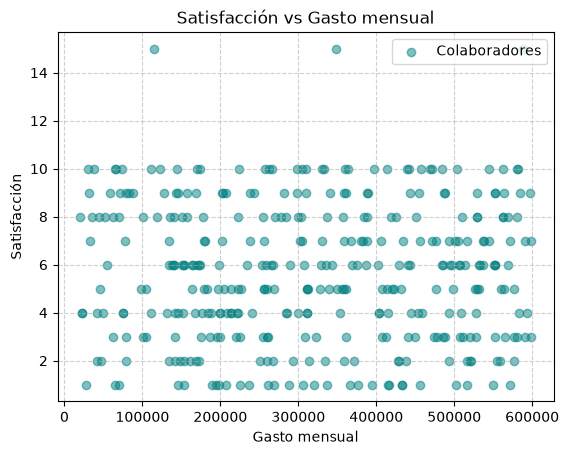

In [13]:
# P9: Relación entre satisfacción y gasto mensual
correlacion = df_clean['satisfaccion'].corr(df_clean['gasto_mensual'])
print(f'Correlación satisfacción vs gasto mensual: {correlacion:.2f}')

plt.scatter(df_clean['gasto_mensual'], df_clean['satisfaccion'], alpha=0.5, color='teal', label='Colaboradores')
plt.xlabel('Gasto mensual')
plt.ylabel('Satisfacción')
plt.title('Satisfacción vs Gasto mensual')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### P10. Evolución del ingreso promedio por año de ingreso
Agrupamos por `anio_ingreso` (extraído en la CELDA 4) y graficamos con `.plot()`.

anio_ingreso
2020.0    1.339095e+06
2021.0    1.289676e+06
2022.0    1.353630e+06
Name: ingreso_mensual, dtype: float64


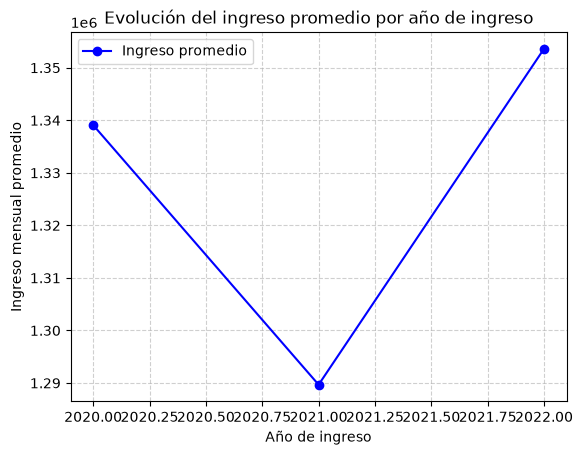

In [14]:
# P10: Evolución del ingreso promedio por año de ingreso
ingreso_por_anio = df_clean.groupby('anio_ingreso')['ingreso_mensual'].mean()
print(ingreso_por_anio)

ingreso_por_anio.plot(marker='o', color='blue', label='Ingreso promedio')
plt.xlabel('Año de ingreso')
plt.ylabel('Ingreso mensual promedio')
plt.title('Evolución del ingreso promedio por año de ingreso')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 🔴 Nivel Avanzado (Preguntas 11–15)

11- P11. Ranking de departamentos por evaluación promedio (¿qué área rinde mejor?)
12- P12. Segmentación por nivel de ingreso: ¿cuántos son Alto / Medio / Bajo?
13- P13. Gráfico de barras: Top 10 departamentos por gasto mensual total
14- P14. Mapa de calor: ingreso promedio por ciudad × modalidad
15- P15. Exportar el dataset limpio + resumen comercial

### P11. Ranking de departamentos por evaluación promedio
Mismo patrón `groupby().mean().sort_values()` usado en preguntas anteriores, ahora sobre `evaluacion`.

In [15]:
# P11: Ranking de departamentos por evaluación promedio
evaluacion_por_depto = df_clean.groupby('departamento')['evaluacion'].mean().sort_values(ascending=False)
print(evaluacion_por_depto)
print(f'\nDepartamento con mejor evaluación promedio: {evaluacion_por_depto.idxmax()}')

departamento
Finanzas     4.501449
RRHH         4.044928
TI           3.883582
Ventas       3.826829
Marketing    3.811111
Name: evaluacion, dtype: float64

Departamento con mejor evaluación promedio: Finanzas


### P12. Segmentación por nivel de ingreso
Definimos los cortes con los terciles (33% y 66%) de `ingreso_mensual` y clasificamos cada colaborador en Bajo/Medio/Alto con una función aplicada con `.apply()`, luego contamos con `value_counts()`.

In [16]:
# P12: Segmentación por nivel de ingreso (Alto / Medio / Bajo)
corte_bajo = df_clean['ingreso_mensual'].quantile(0.33)
corte_alto = df_clean['ingreso_mensual'].quantile(0.66)

def segmentar_ingreso(valor):
    if valor <= corte_bajo:
        return 'Bajo'
    elif valor <= corte_alto:
        return 'Medio'
    else:
        return 'Alto'

df_clean['segmento_ingreso'] = df_clean['ingreso_mensual'].apply(segmentar_ingreso)
segmento_counts = df_clean['segmento_ingreso'].value_counts()
print(segmento_counts)

segmento_ingreso
Alto     119
Bajo     116
Medio    115
Name: count, dtype: int64


### P13. Top 10 departamentos por gasto mensual total (gráfico de barras)
Reutilizamos el `groupby().sum().sort_values().head(10)` de P6 y lo graficamos con `kind='bar'`. Como el dataset solo tiene 5 departamentos, el gráfico muestra los 5 (equivale al "top 10" completo).

departamento
Ventas       26623429
Finanzas     21774235
Marketing    21722516
TI           21037036
RRHH         20540154
Name: gasto_mensual, dtype: int64


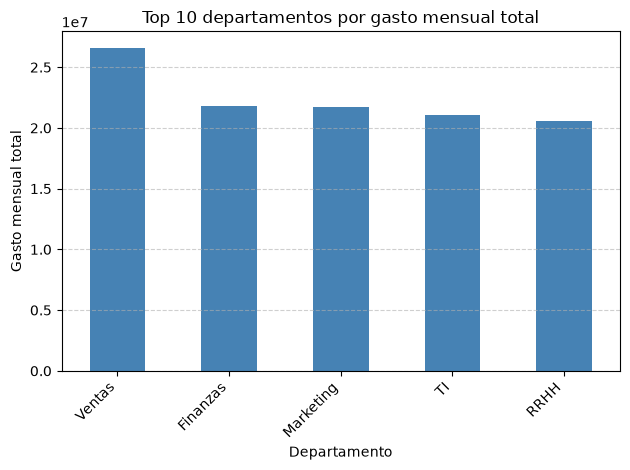

In [17]:
# P13: Top 10 departamentos por gasto mensual total
top10_deptos_gasto = df_clean.groupby('departamento')['gasto_mensual'].sum().sort_values(ascending=False).head(10)
print(top10_deptos_gasto)

top10_deptos_gasto.plot(kind='bar', color='steelblue')
plt.xlabel('Departamento')
plt.ylabel('Gasto mensual total')
plt.title('Top 10 departamentos por gasto mensual total')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### P14. Mapa de calor: ingreso promedio por ciudad × modalidad
Construimos una tabla pivote con `pivot_table` (ciudad en filas, modalidad en columnas, promedio de `ingreso_mensual`) y la visualizamos con `sns.heatmap`.

modalidad     Híbrido  Presencial     Remoto
ciudad                                      
Concepción  1400559.0   1354149.0  1330737.0
La Serena   1310918.0   1436824.0  1356376.0
Santiago    1331432.0   1327537.0  1232701.0
Temuco      1314858.0   1404580.0  1185984.0
Valparaíso  1397953.0   1320700.0  1175842.0


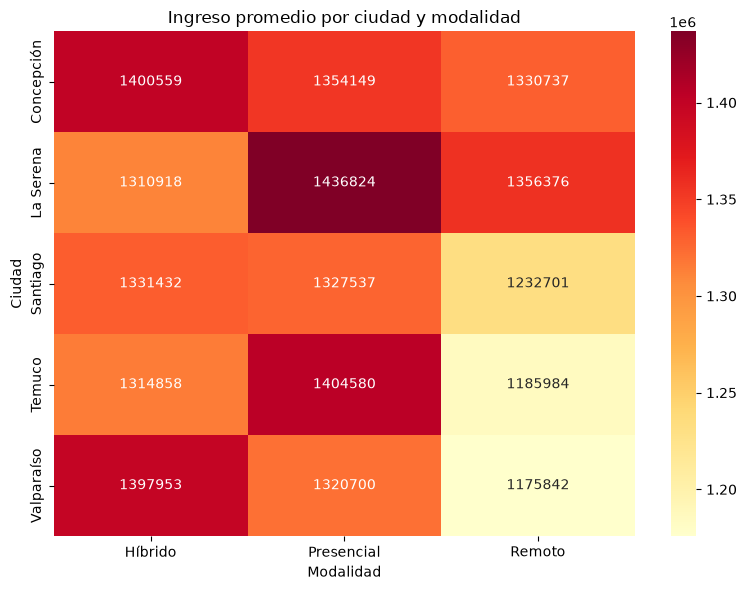

In [18]:
# P14: Mapa de calor - ingreso promedio por ciudad x modalidad
tabla_pivote = df_clean.pivot_table(
    index='ciudad', columns='modalidad', values='ingreso_mensual', aggfunc='mean'
)
print(tabla_pivote.round(0))

plt.figure(figsize=(8, 6))
sns.heatmap(tabla_pivote, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Ingreso promedio por ciudad y modalidad')
plt.xlabel('Modalidad')
plt.ylabel('Ciudad')
plt.tight_layout()
plt.show()

### P15. Exportar dataset limpio + resumen comercial
Cerramos el análisis exportando `df_clean` (el dataset ya limpio) y un `resumen_comercial` con los hallazgos clave de las preguntas anteriores, listo para entregar a dirección.

In [19]:
# P15: Exportar el dataset limpio + resumen comercial
df_clean.to_excel('output/Dataset_S7_limpio.xlsx', index=False)

resumen_comercial = pd.DataFrame({
    'Métrica': [
        'Colaboradores únicos',
        'Ingreso mensual promedio',
        'Gasto mensual total',
        'Departamento con mayor gasto',
        'Modalidad con mayor ingreso promedio',
        'Ciudad con mayor gasto total',
        'Correlación satisfacción-gasto',
        'Departamento con mejor evaluación',
    ],
    'Valor': [
        n_unicos,
        round(ingreso_promedio, 0),
        round(gasto_total, 0),
        gasto_por_depto.idxmax(),
        ingreso_por_modalidad.idxmax(),
        top5_ciudades_gasto.idxmax(),
        round(correlacion, 2),
        evaluacion_por_depto.idxmax(),
    ]
})

resumen_comercial.to_excel('output/Resumen_comercial.xlsx', index=False)
print(resumen_comercial.to_string(index=False))
print('\nArchivos exportados en la carpeta output/:')
print(' - Dataset_S7_limpio.xlsx')
print(' - Resumen_comercial.xlsx')

                             Métrica      Valor
                Colaboradores únicos        350
            Ingreso mensual promedio  1320447.0
                 Gasto mensual total  111697370
        Departamento con mayor gasto     Ventas
Modalidad con mayor ingreso promedio Presencial
        Ciudad con mayor gasto total   Santiago
      Correlación satisfacción-gasto        0.0
   Departamento con mejor evaluación   Finanzas

Archivos exportados en la carpeta output/:
 - Dataset_S7_limpio.xlsx
 - Resumen_comercial.xlsx
